# 2. The Simple Regression Model

In [32]:
import wooldridge as woo
import numpy as np
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import pandas as pd
import scipy.stats as stats

## 2.1. Simple OLS Regression

> Wooldridge, Example 2.3: CEO Salary and Return on Equity

In [8]:
ceosal1 = woo.dataWoo('ceosal1')
x = ceosal1['roe']
print(f'x shape: {x.shape}')
y = ceosal1['salary']
print(f'y shape: {y.shape}')

# ingredients to the OLS formulas:
cov_mat = np.cov(x, y)
print(f'covariance matrix shape: {cov_mat.shape}')
cov_xy = cov_mat[1, 0]  # access 2. row and 1. column of covariance matrix
print(f'covariance of x and y: {cov_xy}')
var_x = np.var(x, ddof=1)
print(f'variance of x: {var_x}')
x_bar = np.mean(x)
y_bar = np.mean(y)

# manual calculation of OLS coefficients:
b1 = cov_xy / var_x
b0 = y_bar - b1 * x_bar
print(f'b1: {b1}')
print(f'b0: {b0}')

x shape: (209,)
y shape: (209,)
covariance matrix shape: (2, 2)
covariance of x and y: 1342.5383979609717
variance of x: 72.5649897747341
b1: 18.501186345214933
b0: 963.1913364725576


> Wooldridge, Example 2.3: CEO Salary and Return on Equity (cont’ed)

In [12]:
ceosal1 = woo.dataWoo('ceosal1')
print(f'ceosal1 shape: {ceosal1.shape}')
print(ceosal1[['salary', 'roe']].head(3))

reg = smf.ols(formula='salary ~ roe', data=ceosal1)
results = reg.fit()
# b0 is labeled Intercept
# b1 is labeled with the explanatory variable
b = results.params
print(f'b: \n{b}\n')

ceosal1 shape: (209, 12)
   salary   roe
0    1095  14.1
1    1001  10.9
2    1122  23.5
b: 
Intercept    963.191336
roe           18.501186
dtype: float64



Text(0.5, 0, 'roe')

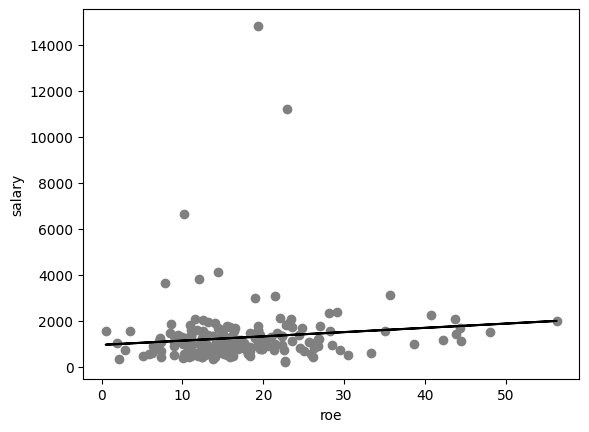

In [13]:
# scatter plot and fitted values:
plt.plot('roe', 'salary', data=ceosal1, color='grey', marker='o', linestyle='')
plt.plot(ceosal1['roe'], results.fittedvalues, color='black', linestyle='-')
plt.ylabel('salary')
plt.xlabel('roe')
# plt.savefig('PyGraphs/Example-2-3-3.pdf')

> Wooldridge, Example 2.4: Wage and Education

In [15]:
wage1 = woo.dataWoo('wage1')
print(f'wage1 shape: {wage1.shape}')
print(wage1[['wage', 'educ']].head(3))

reg = smf.ols(formula='wage ~ educ', data=wage1)
results = reg.fit()
b = results.params
print(f'b: \n{b}\n')

wage1 shape: (526, 24)
   wage  educ
0  3.10    11
1  3.24    12
2  3.00    11
b: 
Intercept   -0.904852
educ         0.541359
dtype: float64



> Wooldridge, Example 2.5: Voting Outcomes and Campaign Expenditures

vote 1 shape: (173, 10)
   voteA     shareA
0     68  97.407669
1     62  60.881039
2     73  97.014763
b: 
Intercept    26.812214
shareA        0.463827
dtype: float64



Text(0.5, 0, 'shareA')

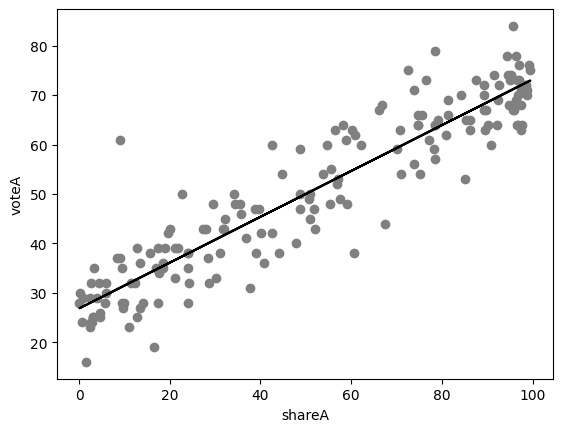

In [16]:
vote1 = woo.dataWoo('vote1')
print(f'vote 1 shape: {vote1.shape}')
print(vote1[['voteA', 'shareA']].head(3))

# OLS regression:
reg = smf.ols(formula='voteA ~ shareA', data=vote1)
results = reg.fit()
b = results.params
print(f'b: \n{b}\n')

# scatter plot and fitted values:
plt.plot('shareA', 'voteA', data=vote1, color='grey', marker='o', linestyle='')
plt.plot(vote1['shareA'], results.fittedvalues, color='black', linestyle='-')
plt.ylabel('voteA')
plt.xlabel('shareA')
# plt.savefig('PyGraphs/Example-2-5.pdf')

## 2.2. Coefficients, Fitted Values, and Residuals

> Wooldridge, Example 2.6: CEO Salary and Return on Equity

In [20]:
ceosal1 = woo.dataWoo('ceosal1')

# OLS regression:
reg = smf.ols(formula='salary ~ roe', data=ceosal1)
results = reg.fit()

# obtain predicted values and residuals:
salary_hat = results.fittedvalues
u_hat = results.resid

# Wooldridge, Table 2.2:
table = pd.DataFrame({'roe': ceosal1['roe'],
                      'salary': ceosal1['salary'],
                      'salary_hat': salary_hat,
                      'u_hat': u_hat})
print(f'table.head(15): \n{table.head(15)}\n')

table.head(15): 
          roe  salary   salary_hat       u_hat
0   14.100000    1095  1224.058071 -129.058071
1   10.900000    1001  1164.854261 -163.854261
2   23.500000    1122  1397.969216 -275.969216
3    5.900000     578  1072.348338 -494.348338
4   13.800000    1368  1218.507712  149.492288
5   20.000000    1145  1333.215063 -188.215063
6   16.400000    1078  1266.610785 -188.610785
7   16.299999    1094  1264.760660 -170.760660
8   10.500000    1237  1157.453793   79.546207
9   26.299999     833  1449.772523 -616.772523
10  25.900000     567  1442.372056 -875.372056
11  26.799999     933  1459.023116 -526.023116
12  14.800000    1339  1237.008898  101.991102
13  22.299999     937  1375.767778 -438.767778
14  56.299999    2011  2004.808114    6.191886



> Wooldridge, Example 2.7: Wage and Education

In [21]:
wage1 = woo.dataWoo('wage1')
reg = smf.ols(formula='wage ~ educ', data=wage1)
results = reg.fit()

# obtain coefficients, predicted values and residuals:
b = results.params
wage_hat = results.fittedvalues
u_hat = results.resid

# confirm property (1):
u_hat_mean = np.mean(u_hat)
print(f'u_hat_mean: {u_hat_mean}\n')

# confirm property (2):
educ_u_cov = np.cov(wage1['educ'], u_hat)[1, 0]
print(f'educ_u_cov: {educ_u_cov}\n')

# confirm property (3):
educ_mean = np.mean(wage1['educ'])
wage_pred = b.iloc[0] + b.iloc[1] * educ_mean
print(f'wage_pred: {wage_pred}\n')

wage_mean = np.mean(wage1['wage'])
print(f'wage_mean: {wage_mean}\n')

u_hat_mean: -7.618747204728071e-15

educ_u_cov: -2.1992989440193578e-15

wage_pred: 5.896102674787043

wage_mean: 5.896102674787035



## 2.3. Goodness of Fit

> Wooldridge, Example 2.8: CEO Salary and Return on Equity

In [22]:
ceosal1 = woo.dataWoo('ceosal1')

# OLS regression:
reg = smf.ols(formula='salary ~ roe', data=ceosal1)
results = reg.fit()

# calculate predicted values & residuals:
sal_hat = results.fittedvalues
u_hat = results.resid

# calculate R^2 in three different ways:
sal = ceosal1['salary']
R2_a = np.var(sal_hat, ddof=1) / np.var(sal, ddof=1)
R2_b = 1 - np.var(u_hat, ddof=1) / np.var(sal, ddof=1)
R2_c = np.corrcoef(sal, sal_hat)[1, 0] ** 2

print(f'R2_a: {R2_a}\n')
print(f'R2_b: {R2_b}\n')
print(f'R2_c: {R2_c}\n')

R2_a: 0.013188624081034115

R2_b: 0.01318862408103405

R2_c: 0.013188624081034085



> Wooldridge, Example 2.9: Voting Outcomes and Campaign Expenditures

In [23]:
vote1 = woo.dataWoo('vote1')

# OLS regression:
reg = smf.ols(formula='voteA ~ shareA', data=vote1)
results = reg.fit()

# print results using summary:
print(f'results.summary(): \n{results.summary()}\n')

# print regression table:
table = pd.DataFrame({'b': round(results.params, 4),
                      'se': round(results.bse, 4),
                      't': round(results.tvalues, 4),
                      'pval': round(results.pvalues, 4)})
print(f'table: \n{table}\n')

results.summary(): 
                            OLS Regression Results                            
Dep. Variable:                  voteA   R-squared:                       0.856
Model:                            OLS   Adj. R-squared:                  0.855
Method:                 Least Squares   F-statistic:                     1018.
Date:                Sun, 10 May 2026   Prob (F-statistic):           6.63e-74
Time:                        20:04:25   Log-Likelihood:                -565.20
No. Observations:                 173   AIC:                             1134.
Df Residuals:                     171   BIC:                             1141.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     26.8122      0.887

## 2.4. Nonlinearities

> Wooldridge, Example 2.10: Wage and Education

In [25]:
wage1 = woo.dataWoo('wage1')

# estimate log-level model:
reg = smf.ols(formula='np.log(wage) ~ educ', data=wage1)
results = reg.fit()
b = results.params
print(f'b: \n{b}\n')

b: 
Intercept    0.583773
educ         0.082744
dtype: float64



> Wooldridge, Example 2.11: CEO Salary and Firm Sales

In [26]:
ceosal1 = woo.dataWoo('ceosal1')

# estimate log-log model:
reg = smf.ols(formula='np.log(salary) ~ np.log(sales)', data=ceosal1)
results = reg.fit()
b = results.params
print(f'b: \n{b}\n')

b: 
Intercept        4.821996
np.log(sales)    0.256672
dtype: float64



## 2.5. Regression through the Origin and Regression on a Constant

> **SLR-Origin-Const.py**: a linear regression model without a slope parameter, i.e. with a constant only

b_1: 
Intercept    963.191336
roe           18.501186
dtype: float64

b_2: 
roe    63.537955
dtype: float64

b_3: 
Intercept    1281.119617
dtype: float64

sal_mean: 1281.1196172248804



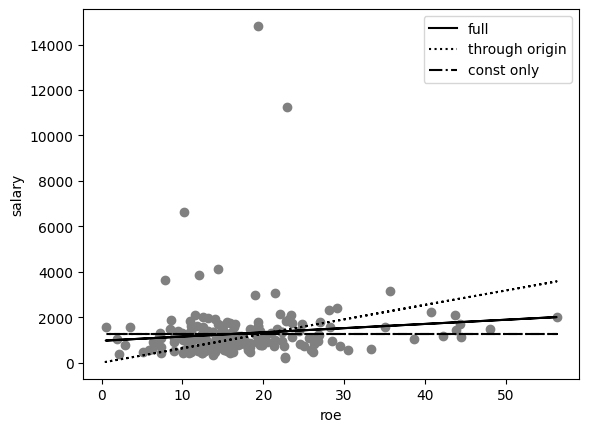

In [27]:
ceosal1 = woo.dataWoo('ceosal1')

# usual OLS regression:
reg1 = smf.ols(formula='salary ~ roe', data=ceosal1)
results1 = reg1.fit()
b_1 = results1.params
print(f'b_1: \n{b_1}\n')

# regression without intercept (through origin):
reg2 = smf.ols(formula='salary ~ 0 + roe', data=ceosal1)
results2 = reg2.fit()
b_2 = results2.params
print(f'b_2: \n{b_2}\n')

# regression without slope (on a constant):
reg3 = smf.ols(formula='salary ~ 1', data=ceosal1)
results3 = reg3.fit()
b_3 = results3.params
print(f'b_3: \n{b_3}\n')

# average y:
sal_mean = np.mean(ceosal1['salary'])
print(f'sal_mean: {sal_mean}\n')

# scatter plot and fitted values:
plt.plot('roe', 'salary', data=ceosal1, color='grey', marker='o',
         linestyle='', label='')
plt.plot(ceosal1['roe'], results1.fittedvalues, color='black',
         linestyle='-', label='full')
plt.plot(ceosal1['roe'], results2.fittedvalues, color='black',
         linestyle=':', label='through origin')
plt.plot(ceosal1['roe'], results3.fittedvalues, color='black',
         linestyle='-.', label='const only')
plt.ylabel('salary')
plt.xlabel('roe')
plt.legend()
# plt.savefig('PyGraphs/SLR-Origin-Const.pdf')

## 2.6. Expected Values, Variances, and Standard Errors

> Wooldridge, Example 2.12: Student Math Performance and the School Lunch
Program

In [29]:
meap93 = woo.dataWoo('meap93')

# estimate the model and save the results as "results":
reg = smf.ols(formula='math10 ~ lnchprg', data=meap93)
results = reg.fit()

# number of obs.:
n = results.nobs

# SER (standard error of the regression):
u_hat_var = np.var(results.resid, ddof=1)
SER = np.sqrt(u_hat_var) * np.sqrt((n - 1) / (n - 2))
print(f'SER: {SER}\n')

# SE of b0 & b1, respectively:
lnchprg_sq_mean = np.mean(meap93['lnchprg'] ** 2)
# sample standard deviation
lnchprg_var = np.var(meap93['lnchprg'], ddof=1)
# standard erros of the beta_1 estimator
b1_se = SER / (np.sqrt(lnchprg_var)
               * np.sqrt(n - 1)) * np.sqrt(lnchprg_sq_mean)
# standard erros of the beta_0 estimator
b0_se = SER / (np.sqrt(lnchprg_var) * np.sqrt(n - 1))
print(f'b1_se: {b1_se}\n')
print(f'b0_se: {b0_se}\n')

# automatic calculations:
print(f'results.summary(): \n{results.summary()}\n')

SER: 9.565938459482759

b1_se: 0.9975823856755018

b0_se: 0.034839334258369624

results.summary(): 
                            OLS Regression Results                            
Dep. Variable:                 math10   R-squared:                       0.171
Model:                            OLS   Adj. R-squared:                  0.169
Method:                 Least Squares   F-statistic:                     83.77
Date:                Sun, 10 May 2026   Prob (F-statistic):           2.75e-18
Time:                        20:28:09   Log-Likelihood:                -1499.3
No. Observations:                 408   AIC:                             3003.
Df Residuals:                     406   BIC:                             3011.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------

## 2.7. Monte Carlo Simulations

### 2.7.1. One Sample

> **SLR-Sim-Sample.py** shows how to draw a sample which is consistent with Assumptions
SLR.1 through SLR.5.

df shape: (1000, 2)
b: 
Intercept    1.190238
x            0.444255
dtype: float64

x_sq_mean: 17.27675304867723

x_var: 953.7353266586754



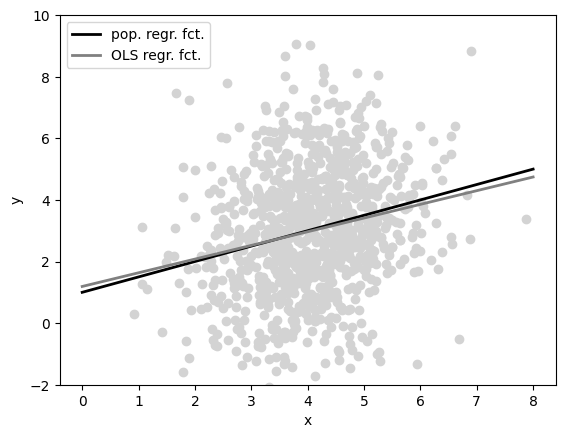

In [34]:
# set the random seed:
np.random.seed(1234567)

# set sample size:
n = 1000

# set true parameters (betas and sd of u):
beta0 = 1
beta1 = 0.5
su = 2

# draw a sample of size n:
x = stats.norm.rvs(4, 1, size=n)
u = stats.norm.rvs(0, su, size=n)
y = beta0 + beta1 * x + u
df = pd.DataFrame({'y': y, 'x': x})
print(f'df shape: {df.shape}')

# estimate parameters by OLS:
reg = smf.ols(formula='y ~ x', data=df)
results = reg.fit()
b = results.params
print(f'b: \n{b}\n')

# features of the sample for the variance formula:
x_sq_mean = np.mean(x ** 2)
print(f'x_sq_mean: {x_sq_mean}\n')
x_var = np.sum((x - np.mean(x)) ** 2)
print(f'x_var: {x_var}\n')

# graph:
x_range = np.linspace(0, 8, num=100)
plt.ylim([-2, 10])
plt.plot(x, y, color='lightgrey', marker='o', linestyle='')
plt.plot(x_range, beta0 + beta1 * x_range, color='black',
         linestyle='-', linewidth=2, label='pop. regr. fct.')
plt.plot(x_range, b.iloc[0] + b.iloc[1] * x_range, color='grey',
         linestyle='-', linewidth=2, label='OLS regr. fct.')
plt.ylabel('y')
plt.xlabel('x')
plt.legend()
# plt.savefig('PyGraphs/SLR-Sim-Sample.pdf')

### 2.7.2. Many Samples

> **SLR-Sim-Model.py**

In [39]:
# set the random seed:
np.random.seed(1234567)

# set sample size and number of simulations
n = 1000
r = 10000

# set true parameters:
beta0 = 1
beta1 = 0.5
su = 2
sx = 1
ex = 4

# initialize b0 and b1 to store results later:
b0 = np.empty(r)
b1 = np.empty(r)

# repeat r times:
for i in range(r):
    # draw a sample:
    x = stats.norm.rvs(ex, sx, size=n)
    u = stats.norm.rvs(0, su, size=n)
    y = beta0 + beta1 * x + u
    df = pd.DataFrame({'y': y, 'x': x})

    # estimate OLS:
    reg = smf.ols(formula='y ~ x', data=df)
    results = reg.fit()
    b0[i] = results.params['Intercept']
    b1[i] = results.params['x']

> **SLR-Sim-Model-Condx.py**

b0_mean: 1.00329460319241

b1_mean: 0.49936958775965984

b0_var: 0.07158103946245628

b1_var: 0.004157652196227234



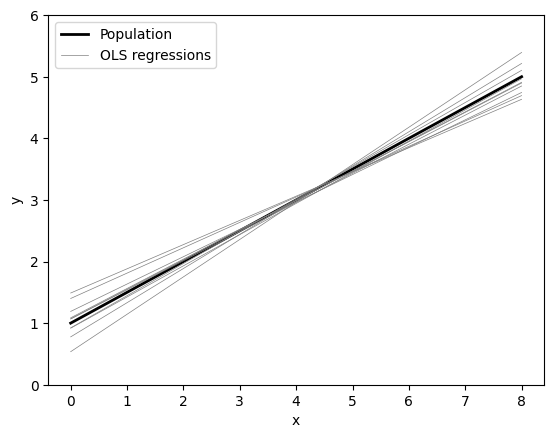

In [35]:
# set the random seed:
np.random.seed(1234567)

# set sample size and number of simulations:
n = 1000
r = 10000

# set true parameters (betas and sd of u):
beta0 = 1
beta1 = 0.5
su = 2

# initialize b0 and b1 to store results later:
b0 = np.empty(r)
b1 = np.empty(r)

# draw a sample of x, fixed over replications:
x = stats.norm.rvs(4, 1, size=n)

# repeat r times:
for i in range(r):
    # draw a sample of y:
    u = stats.norm.rvs(0, su, size=n)
    y = beta0 + beta1 * x + u
    df = pd.DataFrame({'y': y, 'x': x})

    # estimate and store parameters by OLS:
    reg = smf.ols(formula='y ~ x', data=df)
    results = reg.fit()
    b0[i] = results.params['Intercept']
    b1[i] = results.params['x']

# MC estimate of the expected values:
b0_mean = np.mean(b0)
b1_mean = np.mean(b1)

print(f'b0_mean: {b0_mean}\n')
print(f'b1_mean: {b1_mean}\n')

# MC estimate of the variances:
b0_var = np.var(b0, ddof=1)
b1_var = np.var(b1, ddof=1)

print(f'b0_var: {b0_var}\n')
print(f'b1_var: {b1_var}\n')

# graph:
x_range = np.linspace(0, 8, num=100)
plt.ylim([0, 6])

# add population regression line:
plt.plot(x_range, beta0 + beta1 * x_range, color='black',
         linestyle='-', linewidth=2, label='Population')

# add first OLS regression line (to attach a label):
plt.plot(x_range, b0[0] + b1[0] * x_range, color='grey',
         linestyle='-', linewidth=0.5, label='OLS regressions')

# add OLS regression lines no. 2 to 10:
for i in range(1, 10):
    plt.plot(x_range, b0[i] + b1[i] * x_range, color='grey',
             linestyle='-', linewidth=0.5)
plt.ylabel('y')
plt.xlabel('x')
plt.legend()
# plt.savefig('PyGraphs/SLR-Sim-Model-Condx.pdf')

### 2.7.3. Violation of SLR.4

> **SLR-Sim-Model-ViolSLR4.py**

In [37]:
# set the random seed:
np.random.seed(1234567)

# set sample size and number of simulations:
n = 1000
r = 10000

# set true parameters (betas and sd of u):
beta0 = 1
beta1 = 0.5
su = 2

# initialize b0 and b1 to store results later:
b0 = np.empty(r)
b1 = np.empty(r)

# draw a sample of x, fixed over replications:
x = stats.norm.rvs(4, 1, size=n)

# repeat r times:
for i in range(r):
    # draw a sample of y:
    u_mean = np.array((x - 4) / 5)
    u = stats.norm.rvs(u_mean, su, size=n)
    y = beta0 + beta1 * x + u
    df = pd.DataFrame({'y': y, 'x': x})

    # estimate and store parameters by OLS:
    reg = smf.ols(formula='y ~ x', data=df)
    results = reg.fit()
    b0[i] = results.params['Intercept']
    b1[i] = results.params['x']

# MC estimate of the expected values:
b0_mean = np.mean(b0)
b1_mean = np.mean(b1)

print(f'b0_mean: {b0_mean}\n')
print(f'b1_mean: {b1_mean}\n')

# MC estimate of the variances:
b0_var = np.var(b0, ddof=1)
b1_var = np.var(b1, ddof=1)

print(f'b0_var: {b0_var}\n')
print(f'b1_var: {b1_var}\n')

b0_mean: 0.2032946031924096

b1_mean: 0.6993695877596598

b0_var: 0.07158103946245628

b1_var: 0.004157652196227234



### 2.7.4. Violation of SLR.5

> **SLR-Sim-Model-ViolSLR5.py**

In [38]:
# set the random seed:
np.random.seed(1234567)

# set sample size and number of simulations:
n = 1000
r = 10000

# set true parameters (betas):
beta0 = 1
beta1 = 0.5

# initialize b0 and b1 to store results later:
b0 = np.empty(r)
b1 = np.empty(r)

# draw a sample of x, fixed over replications:
x = stats.norm.rvs(4, 1, size=n)

# repeat r times:
for i in range(r):
    # draw a sample of y:
    u_var = np.array(4 / np.exp(4.5) * np.exp(x))
    u = stats.norm.rvs(0, np.sqrt(u_var), size=n)
    y = beta0 + beta1 * x + u
    df = pd.DataFrame({'y': y, 'x': x})

    # estimate and store parameters by OLS:
    reg = smf.ols(formula='y ~ x', data=df)
    results = reg.fit()
    results = reg.fit()
    b0[i] = results.params['Intercept']
    b1[i] = results.params['x']

# MC estimate of the expected values:
b0_mean = np.mean(b0)
b1_mean = np.mean(b1)

print(f'b0_mean: {b0_mean}\n')
print(f'b1_mean: {b1_mean}\n')

# MC estimate of the variances:
b0_var = np.var(b0, ddof=1)
b1_var = np.var(b1, ddof=1)

print(f'b0_var: {b0_var}\n')
print(f'b1_var: {b1_var}\n')

b0_mean: 1.001414297039418

b1_mean: 0.4997594115253497

b0_var: 0.1317554449265673

b1_var: 0.010016166348092532

